# GKYZ Volatility Regime × Bond-Yield Trend — Verification

`vnindex_bond_yield_correlation.ipynb` established that yields and the VN-Index
are contemporaneously negatively related, with **no** predictive power in the
mean. This notebook tests whether the yield trend is still worth having as a
**second state variable** next to the existing GKYZ volatility regime
(`app/services/indicators/regime_signals.py`).

## The four claims under test

| # | Claim | Falsified if |
|--|--|--|
| **C1** | The 2×2 (GKYZ × yield trend) separates forward returns, and the ordering is monotone | cells are unordered, or the spread vanishes |
| **C2** | The two states are near-independent — the yield state adds a *new* axis | boolean correlation is large, or cells are badly unbalanced |
| **C3** | The yield trend predicts forward **realized volatility** (the strong claim) | r ≈ 0, or the sign flips across lookbacks |
| **C4** | The split survives out-of-sample and isn't a knife-edge in the parameters | it only works for one tenor/window/band, or dies OOS |

Plus **C5**: does plain absolute volatility (`normalize=False`) already capture
whatever the yield state adds? If so, no new data dependency is needed.

## Ground rules

* Every state is built from data **through `t` only**; returns are measured from
  `t → t+1`. No overlap in the headline tests, so no HAC games are needed.
* Yields are stale on 9–23% of days depending on tenor, so the state uses a
  **multi-day** difference, never a 1-day one.
* `GKYZ normalize=True` is a **rolling min–max over 21 days** — it measures
  volatility *relative to the last month*, not its absolute level. That
  distinction turns out to be the whole reason these two states are complementary.

In [64]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
import backend.app.services.indicators
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)
sys.modules.setdefault('app.services.indicators', backend.app.services.indicators)

from backend.app.services.data_loader import load_stocks
from backend.app.services.indicators.gkyz_volatility import calculate_gkyz_volatility
from backend.app.services.indicators.regime_signals import (
    gkyz_hysteresis, GKYZ_WINDOW, GKYZ_UPPER, GKYZ_LOWER,
)

plt.style.use('dark_background')

# ── chart system (validated on the #1a1a19 surface) ─────────────────────────
SURFACE = '#1a1a19'
INK     = '#c3c2b7'
GRID    = '#3a3a37'
SLOT    = ['#3987e5', '#d95926', '#199e70', '#c98500']   # fixed order, never cycled
CORR_CMAP = LinearSegmentedColormap.from_list(
    'corr_div', ['#3987e5', '#6f8fa8', '#4a4a47', '#a8734a', '#d95926'], N=256)

def style_axes(ax, ylabel=None, title=None):
    ax.grid(True, color=GRID, alpha=0.35, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK, labelsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK, fontsize=9)
    if title:
        ax.set_title(title, color='white', fontsize=11, loc='left', pad=8)
    return ax

# ── config ──────────────────────────────────────────────────────────────────
BENCHMARK    = 'VNINDEX'
DATA_START   = '2016-01-01'
TENORS       = ['VIETNAM_1Y', 'VIETNAM_5Y', 'VIETNAM_10Y']
LABEL        = {'VIETNAM_1Y': '1Y', 'VIETNAM_5Y': '5Y', 'VIETNAM_10Y': '10Y'}

YIELD_SYMBOL = 'VIETNAM_10Y'   # strongest link in the correlation notebook
YIELD_WINDOW = 21              # trailing days for the yield trend
YIELD_BAND   = 0.20            # pp deadband, mirrors GKYZ's hysteresis
VOL_H        = 21              # forward window for realized vol
IS_FRAC      = 0.7             # in-sample fraction for the OOS check

STATE_NAMES  = ['off·falling', 'off·rising', 'ON·falling', 'ON·rising']
STATE_COLOR  = dict(zip(STATE_NAMES, SLOT))

print(f'GKYZ defaults from the repo: window={GKYZ_WINDOW} upper={GKYZ_UPPER} lower={GKYZ_LOWER}')

GKYZ defaults from the repo: window=21 upper=0.8 lower=0.2


## 1. Load

VNINDEX OHLC from the standard loader (GKYZ needs all four prices). Yields from
the Delta table when it has been backfilled, otherwise straight from the wichart
endpoint — same fallback as the correlation notebook.

In [65]:
df_raw = load_stocks(exclude=[], refresh=False).loc[DATA_START:]
ohlc = pd.DataFrame({f: df_raw[f][BENCHMARK] for f in ('open', 'high', 'low', 'close')})
print(f'{BENCHMARK}: {len(ohlc)} bars  {ohlc.index[0].date()} -> {ohlc.index[-1].date()}')

# yields = df_raw['close']['VIETNAM_10Y']
# yields.tail(20)
# Bond-yield levels (percent), bars x tenor, straight from df_raw.
yields = df_raw['close'][TENORS].reindex(ohlc.index).ffill(limit=5)
print(f'yields: {len(yields)} rows, tenors {list(yields.columns)}')

# Staleness check — this is why the state uses a multi-day difference.
stale = pd.DataFrame({
    'unchanged days': (yields.diff() == 0).mean().round(3),
    'longest flat run': [int((lambda s: s.groupby((s != s.shift()).cumsum()).sum().max())
                             (yields[t].diff() == 0)) for t in yields.columns],
}, index=yields.columns).rename(index=LABEL)
stale

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2538, 1000)  |  2016-08-22 → 2026-08-19
VNINDEX: 2538 bars  2016-08-22 -> 2026-08-19
yields: 2538 rows, tenors ['VIETNAM_1Y', 'VIETNAM_5Y', 'VIETNAM_10Y']


,unchanged days,longest flat run
symbol,,
1Y,0.243,11
5Y,0.104,5
10Y,0.099,5


## 2. Build the two states

`gkyz_hysteresis` is imported from the repo, so this is the *same* regime the
backtests gate on — not a reimplementation.

`yield_trend_regime` is new. It mirrors the GKYZ idiom: a sticky boolean with a
deadband, so it does not whipsaw when the trailing change hovers near zero. If
this notebook validates, it moves into `regime_signals.py` as-is.

In [66]:
def yield_trend_regime(yields: pd.Series, window: int = YIELD_WINDOW,
                       band: float = YIELD_BAND) -> pd.Series:
    '''Sticky rising/falling state for a bond-yield series.

    True  = yields rising (equity headwind); flips on a trailing `window`-day
            change above +band, and back only below -band.
    '''
    dy = yields.diff(window)
    state, out = False, []
    for v in dy.to_numpy():
        if not np.isnan(v):
            if not state and v > band:
                state = True
            elif state and v < -band:
                state = False
        out.append(state)
    return pd.Series(out, index=yields.index)


risk_on  = gkyz_hysteresis(ohlc['open'].values, ohlc['high'].values,
                           ohlc['low'].values, ohlc['close'].values,
                           index=ohlc.index)                 # True = HIGH vol
rates_up = yield_trend_regime(yields[YIELD_SYMBOL])          # True = rising

ret = np.log(ohlc['close']).diff()

# Forward windows, written out explicitly so there is no shift() ambiguity:
# fwd_ret[t] is the t -> t+1 return; fwd_vol[t] uses r[t+1 .. t+VOL_H].
r_np = ret.to_numpy()
fwd_ret = ret.shift(-1)
fwd_vol = pd.Series(
    [r_np[i + 1: i + 1 + VOL_H].std() if i + 1 + VOL_H <= len(r_np) else np.nan
     for i in range(len(r_np))], index=ret.index)

state_lbl = pd.Series(np.where(risk_on, 'ON·', 'off·'), index=ohlc.index) + \
            pd.Series(np.where(rates_up, 'rising', 'falling'), index=ohlc.index)

D = pd.DataFrame({'fwd_ret': fwd_ret, 'fwd_vol': fwd_vol, 'risk_on': risk_on,
                  'rates_up': rates_up, 'state': state_lbl,
                  'dy': yields[YIELD_SYMBOL].diff(YIELD_WINDOW)}).dropna()

print(f'usable rows: {len(D)}  |  {D.index[0].date()} -> {D.index[-1].date()}')
print(f'GKYZ risk-ON {D["risk_on"].mean():.0%} of days   '
      f'rates rising {D["rates_up"].mean():.0%} of days')
D['state'].value_counts().rename('days').to_frame()

usable rows: 2496  |  2016-09-21 -> 2026-07-21
GKYZ risk-ON 47% of days   rates rising 48% of days


,days
state,
off·falling,704
off·rising,631
ON·falling,596
ON·rising,565


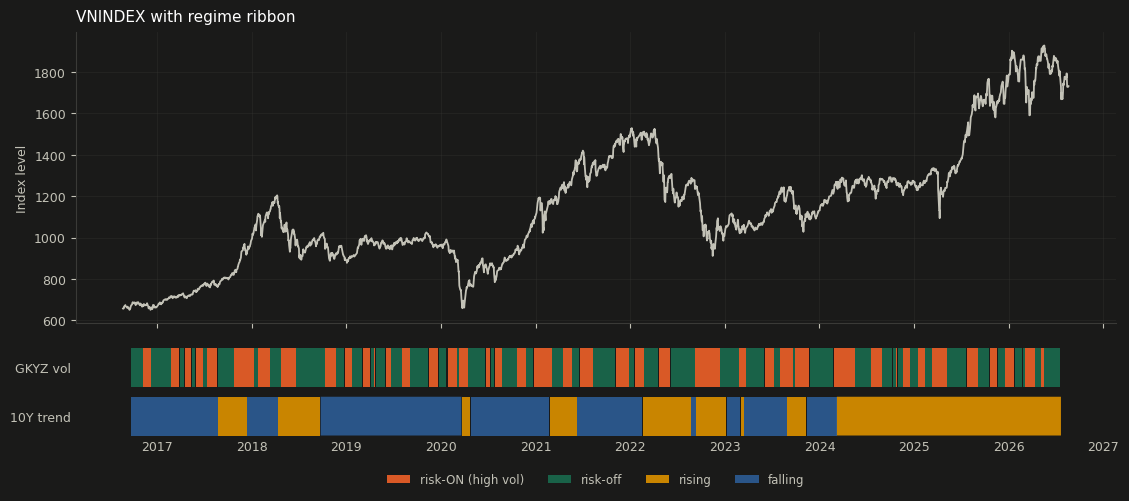

In [67]:
# Index with a state ribbon underneath — two booleans read far better as strips
# than as shading behind the price, which would need four overlapping colours.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5.6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)

ax1.plot(ohlc.index, ohlc['close'], color=INK, linewidth=1.3)
style_axes(ax1, 'Index level', f'{BENCHMARK} with regime ribbon')

from matplotlib.patches import Patch

ribbons = [(D['risk_on'],  'GKYZ vol',  'risk-ON (high vol)', 'risk-off', SLOT[1], SLOT[2]),
           (D['rates_up'], f'{LABEL[YIELD_SYMBOL]} trend', 'rising', 'falling', SLOT[3], SLOT[0])]
handles = []
for row, (series, name, on_lbl, off_lbl, c_on, c_off) in enumerate(ribbons):
    y = 1 - row
    ax2.fill_between(series.index, y, y + 0.8, where=series.values,
                     color=c_on, step='post', linewidth=0)
    ax2.fill_between(series.index, y, y + 0.8, where=~series.values,
                     color=c_off, step='post', linewidth=0, alpha=0.55)
    handles += [Patch(facecolor=c_on, label=on_lbl),
                Patch(facecolor=c_off, alpha=0.55, label=off_lbl)]

ax2.set_ylim(0, 2)
ax2.set_yticks([1.4, 0.4], [r[1] for r in ribbons])
for s in ax2.spines.values():
    s.set_visible(False)
ax2.tick_params(colors=INK, labelsize=9, length=0)
ax2.legend(handles=handles, frameon=False, labelcolor=INK, fontsize=8.5,
           ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.28))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.subplots_adjust(hspace=0.08, left=0.10, bottom=0.16)
plt.show()

## 3. C1 — does the 2×2 separate forward returns?

Next-day returns only, so every observation is independent and the annualised
figures are honest. Welch's t-test compares rising vs falling *within* each GKYZ
state — that is the question that matters, since GKYZ is already in the strategy.

In [68]:
def two_by_two(risk_on_s, rates_up_s, fwd_r, fwd_v=None, label=''):
    rows = []
    for ro in (False, True):
        for ru in (False, True):
            m = (risk_on_s == ro) & (rates_up_s == ru)
            if m.sum() < 30:
                continue
            r = fwd_r[m]
            rec = {
                'GKYZ': 'risk-ON (high vol)' if ro else 'risk-off (low vol)',
                'rates': 'rising' if ru else 'falling',
                'days': int(m.sum()), 'share': f'{m.mean():.0%}',
                'ann.ret': round(r.mean() * 252 * 100, 1),
                'ann.vol': round(r.std() * np.sqrt(252) * 100, 1),
                'Sharpe': round(r.mean() / r.std() * np.sqrt(252), 2),
                'hit': f'{(r > 0).mean():.0%}',
            }
            if fwd_v is not None:
                rec['fwd 21d vol'] = round(fwd_v[m].mean() * np.sqrt(252) * 100, 1)
            rows.append(rec)
    return pd.DataFrame(rows)


tbl = two_by_two(D['risk_on'], D['rates_up'], D['fwd_ret'], D['fwd_vol'])
print(tbl.to_string(index=False), '\n')

for ro in (False, True):
    a = D[(D['risk_on'] == ro) & (D['rates_up'])]['fwd_ret']
    b = D[(D['risk_on'] == ro) & (~D['rates_up'])]['fwd_ret']
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f'{"risk-ON " if ro else "risk-off"}: rising vs falling  '
          f'Δann.ret={(a.mean() - b.mean()) * 252 * 100:+.1f}pp   t={t:+.2f}  p={p:.3f}'
          f'   {"SIGNIFICANT" if p < 0.05 else "not significant at 5%"}')

mono = tbl.sort_values('ann.ret', ascending=False)['ann.ret'].tolist()
print(f'\nC1 ordering: {mono}  ->  '
      f'{"monotone" if mono == sorted(mono, reverse=True) else "NOT monotone"}')

              GKYZ   rates  days share  ann.ret  ann.vol  Sharpe hit  fwd 21d vol
risk-off (low vol) falling   704   28%     18.2     14.4    1.26 57%         13.7
risk-off (low vol)  rising   631   25%      2.3     15.8    0.15 53%         15.5
risk-ON (high vol) falling   596   24%      7.6     19.3    0.39 58%         15.9
risk-ON (high vol)  rising   565   23%      7.5     25.1    0.30 54%         20.6 

risk-off: rising vs falling  Δann.ret=-15.9pp   t=-1.20  p=0.229   not significant at 5%
risk-ON : rising vs falling  Δann.ret=-0.0pp   t=-0.00  p=0.998   not significant at 5%

C1 ordering: [18.2, 7.6, 7.5, 2.3]  ->  monotone


## 4. C2 — are the two states independent?

A second filter that merely restates the first buys nothing. Want: a low boolean
correlation and four reasonably populated cells.

In [69]:
# Force the full 2x2 so a degenerate (single-valued) state shows as an empty
# row/column instead of collapsing the frame and breaking the labels.
ct = (pd.crosstab(D['risk_on'], D['rates_up'], normalize=True)
        .reindex(index=[False, True], columns=[False, True], fill_value=0).round(3))
ct.index = ['risk-off', 'risk-ON']
ct.columns = ['rates falling', 'rates rising']
print(ct.to_string())
rho = D['risk_on'].astype(int).corr(D['rates_up'].astype(int))
print(f'\nboolean state correlation: {rho:+.3f}  ->  '
      f'{"near-independent, adds a new axis" if abs(rho) < 0.3 else "REDUNDANT with GKYZ"}')
print(f'least-populated cell: {ct.values.min():.0%} of days')

          rates falling  rates rising
risk-off          0.282         0.253
risk-ON           0.239         0.226

boolean state correlation: +0.014  ->  near-independent, adds a new axis
least-populated cell: 23% of days


## 5. C3 — does the yield trend predict forward realized volatility?

This is the claim with the most riding on it: GKYZ is a volatility filter, so a
variable that *forecasts* volatility slots in naturally, whereas one that
forecasts returns would have to survive a much higher bar (and, per the
correlation notebook, does not).

In [70]:
rows = []
for t in TENORS:
    for k in (5, 21, 63):
        dyk = yields[t].diff(k).reindex(D.index)
        ok = dyk.notna() & D['fwd_vol'].notna()
        r, p = stats.pearsonr(dyk[ok], D['fwd_vol'][ok])
        rows.append({'tenor': LABEL[t], 'lookback k': k, 'r': round(r, 4),
                     'p': f'{p:.2e}', 'n': int(ok.sum()),
                     'signif': '✓' if p < 0.01 else '·'})
vol_tbl = pd.DataFrame(rows)
print(vol_tbl.to_string(index=False))

same_sign = (np.sign(vol_tbl['r']) == np.sign(vol_tbl['r'].iloc[0])).all()
print(f'\nC3: all {len(vol_tbl)} combinations same sign -> {same_sign}   '
      f'|r| range {vol_tbl["r"].abs().min():.3f}-{vol_tbl["r"].abs().max():.3f}')

tenor  lookback k      r        p    n signif
   1Y           5 0.0649 1.19e-03 2496      ✓
   1Y          21 0.1210 1.33e-09 2496      ✓
   1Y          63 0.2095 9.67e-26 2454      ✓
   5Y           5 0.1309 5.16e-11 2496      ✓
   5Y          21 0.2022 1.92e-24 2496      ✓
   5Y          63 0.2970 3.54e-51 2454      ✓
  10Y           5 0.1399 2.25e-12 2496      ✓
  10Y          21 0.1983 1.47e-23 2496      ✓
  10Y          63 0.2610 1.69e-39 2454      ✓

C3: all 9 combinations same sign -> True   |r| range 0.065-0.297


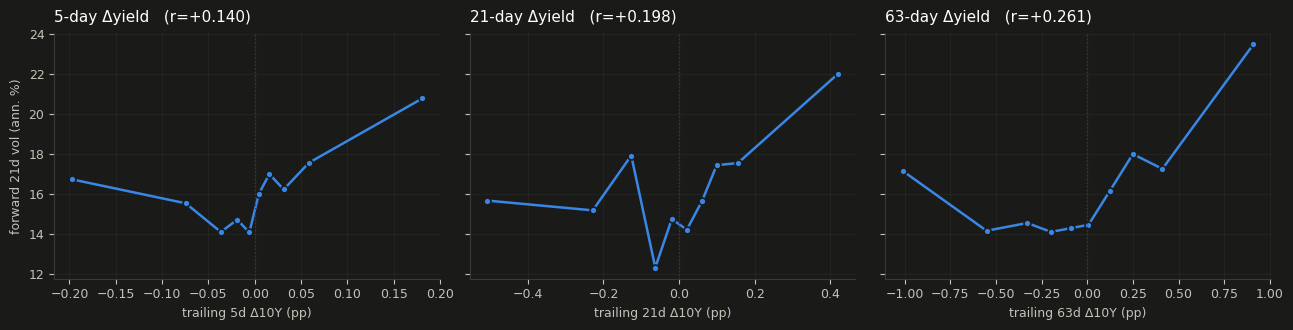

In [71]:
# Deciles of the trailing yield change vs mean forward vol. Binning beats a
# 2,400-point scatter: the relationship is a conditional mean, so show that.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
fig.patch.set_facecolor(SURFACE)

for ax, k in zip(axes, (5, 21, 63)):
    ax.set_facecolor(SURFACE)
    dyk = yields[YIELD_SYMBOL].diff(k).reindex(D.index)
    g = pd.DataFrame({'dy': dyk, 'v': D['fwd_vol'] * np.sqrt(252) * 100}).dropna()
    g['bin'] = pd.qcut(g['dy'], 10, labels=False, duplicates='drop')
    agg = g.groupby('bin').agg(dy=('dy', 'mean'), vol=('v', 'mean'))
    ax.plot(agg['dy'], agg['vol'], color=SLOT[0], linewidth=1.8, marker='o',
            markersize=5, markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.axvline(0, color=GRID, linewidth=1, linestyle=':')
    r, _ = stats.pearsonr(g['dy'], g['v'])
    style_axes(ax, 'forward 21d vol (ann. %)' if k == 5 else None,
               f'{k}-day Δyield   (r={r:+.3f})')
    ax.set_xlabel(f'trailing {k}d Δ{LABEL[YIELD_SYMBOL]} (pp)', color=INK, fontsize=9)

plt.tight_layout()
plt.show()

## 6. C4 — robustness

Three separate ways to break the result:

1. **Split-half** — does the effect exist in both halves of the sample?
2. **Out-of-sample** — build nothing on the OOS slice, just read it.
3. **Parameter sensitivity** — tenor × lookback × deadband. A finding that only
   works at one setting is a finding about that setting.

In [72]:
half = len(D) // 2
rows = []
for name, sl in [('first half', D.iloc[:half]), ('second half', D.iloc[half:])]:
    for ro in (False, True):
        a = sl[(sl['risk_on'] == ro) & (sl['rates_up'])]['fwd_ret']
        b = sl[(sl['risk_on'] == ro) & (~sl['rates_up'])]['fwd_ret']
        if len(a) < 30 or len(b) < 30:
            continue
        rows.append({
            'slice': name, 'period': f'{sl.index[0].date()} → {sl.index[-1].date()}',
            'GKYZ': 'risk-ON' if ro else 'risk-off',
            'falling ann.ret': round(b.mean() * 252 * 100, 1),
            'rising ann.ret': round(a.mean() * 252 * 100, 1),
            'spread (pp)': round((b.mean() - a.mean()) * 252 * 100, 1),
        })
split_tbl = pd.DataFrame(rows)
print(split_tbl.to_string(index=False))

off = split_tbl[split_tbl['GKYZ'] == 'risk-off']['spread (pp)']
print(f'\nC4a: risk-off spread positive in both halves -> {(off > 0).all()}  ({off.tolist()})')

      slice                  period     GKYZ  falling ann.ret  rising ann.ret  spread (pp)
 first half 2016-09-21 → 2021-09-15 risk-off             15.8            18.0         -2.2
 first half 2016-09-21 → 2021-09-15  risk-ON              2.7            46.0        -43.2
second half 2021-09-16 → 2026-07-21 risk-off             23.9            -3.5         27.3
second half 2021-09-16 → 2026-07-21  risk-ON             24.7            -2.8         27.6

C4a: risk-off spread positive in both halves -> False  ([-2.2, 27.3])


In [73]:
GRID_TENORS  = TENORS
GRID_WINDOWS = [5, 21, 63]
GRID_BANDS   = [0.0, 0.10, 0.20]

rows = []
for t in GRID_TENORS:
    for w in GRID_WINDOWS:
        for b in GRID_BANDS:
            ru = yield_trend_regime(yields[t], window=w, band=b).reindex(D.index)
            lo_f = D[(~D['risk_on']) & (~ru)]['fwd_ret']
            lo_r = D[(~D['risk_on']) & (ru)]['fwd_ret']
            if len(lo_f) < 50 or len(lo_r) < 50:
                continue
            rows.append({'tenor': LABEL[t], 'window': w, 'band': b,
                         'spread_pp': (lo_f.mean() - lo_r.mean()) * 252 * 100,
                         'n_rising': len(lo_r)})
sens = pd.DataFrame(rows)
print(f'{len(sens)} parameter combinations, risk-off spread (falling − rising, ann. pp)')
print(f'  positive in {(sens["spread_pp"] > 0).mean():.0%} of them   '
      f'median {sens["spread_pp"].median():+.1f}pp   '
      f'range {sens["spread_pp"].min():+.1f} to {sens["spread_pp"].max():+.1f}')

# The aggregate hides *where* it fails, which is the whole point of the sweep.
per_tenor = sens.groupby('tenor')['spread_pp'].agg(
    combos='size', positive=lambda x: f'{(x > 0).mean():.0%}',
    median=lambda x: round(x.median(), 1),
    worst=lambda x: round(x.min(), 1), best=lambda x: round(x.max(), 1))
print()
print(per_tenor.to_string())
robust_tenors = [t for t in per_tenor.index if sens[sens['tenor'] == t]['spread_pp'].min() > 0]
print(f'\ntenors positive at EVERY setting: {robust_tenors or "none"}')
sens.pivot_table(index=['tenor', 'window'], columns='band', values='spread_pp').round(1)

27 parameter combinations, risk-off spread (falling − rising, ann. pp)
  positive in 89% of them   median +15.9pp   range -13.7 to +34.1

       combos positive  median  worst  best
tenor                                      
10Y         9     100%    22.9   10.6  34.1
1Y          9      67%     5.5  -13.7  27.6
5Y          9     100%    16.5    4.9  27.0

tenors positive at EVERY setting: ['10Y', '5Y']


band           0.0   0.1   0.2
tenor window                  
10Y   5       34.1  26.4  24.1
      21      22.9  21.4  15.9
      63      27.6  10.6  18.5
1Y    5       27.6   5.6   3.0
      21     -13.7  -6.1   7.8
      63      -5.8   5.5  11.0
5Y    5       21.7  11.7  27.0
      21       8.3   4.9  19.3
      63      11.0  17.1  16.5

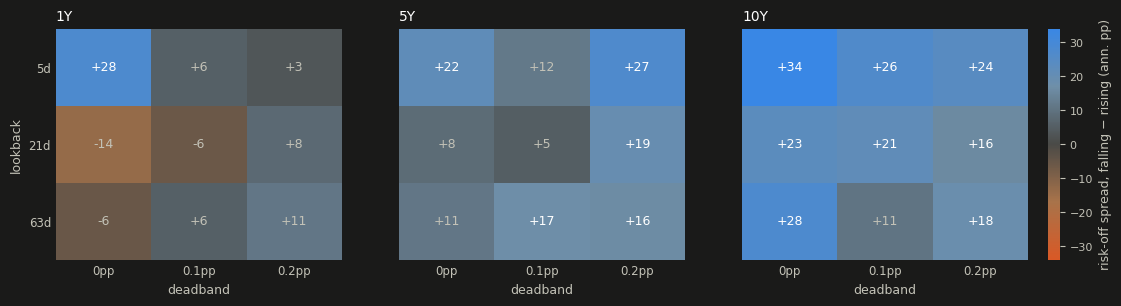

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.0), sharey=True)
fig.patch.set_facecolor(SURFACE)
vmax = float(sens['spread_pp'].abs().max())

for ax, t in zip(axes, [LABEL[x] for x in GRID_TENORS]):
    g = sens[sens['tenor'] == t].pivot(index='window', columns='band', values='spread_pp')
    im = ax.imshow(g.values, cmap=CORR_CMAP.reversed(), vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(g.columns)), [f'{c:g}pp' for c in g.columns], color=INK, fontsize=8.5)
    ax.set_yticks(range(len(g.index)), [f'{i}d' for i in g.index], color=INK, fontsize=8.5)
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            v = g.values[i, j]
            ax.text(j, i, f'{v:+.0f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > vmax * 0.45 else INK)
    ax.set_title(t, color='white', fontsize=10, loc='left', pad=6)
    ax.set_xlabel('deadband', color=INK, fontsize=9)
    ax.set_facecolor(SURFACE)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
axes[0].set_ylabel('lookback', color=INK, fontsize=9)

cb = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
cb.ax.tick_params(colors=INK, labelsize=8)
cb.outline.set_visible(False)
cb.set_label('risk-off spread, falling − rising (ann. pp)', color=INK, fontsize=9)
plt.show()

## 7. C5 — does plain absolute volatility already capture it?

`normalize=True` min–maxes GKYZ over a rolling 21 days, so it tracks volatility
*relative to the last month* and is structurally blind to a slow drift in the
level. If an absolute-volatility state reproduces the yield state's benefit, the
cheaper fix is to change the GKYZ call — no new data dependency.

In [75]:
gk_abs = pd.Series(
    calculate_gkyz_volatility(ohlc['open'].to_numpy(float), ohlc['high'].to_numpy(float),
                              ohlc['low'].to_numpy(float), ohlc['close'].to_numpy(float),
                              window=GKYZ_WINDOW, normalize=False),
    index=ohlc.index).reindex(D.index)

hi_vol_abs = gk_abs > gk_abs.expanding(252).median()      # causal: median to date

print('Correlations between the candidate state variables (as 0/1):')
cand = pd.DataFrame({'GKYZ norm (risk_on)': D['risk_on'].astype(int),
                     'GKYZ absolute > median': hi_vol_abs.astype(int),
                     'rates rising': D['rates_up'].astype(int)}).dropna()
print(cand.corr().round(3).to_string())

print('\nForward-vol prediction, head to head:')
for name, s in [('GKYZ norm (risk_on)', D['risk_on']),
                ('GKYZ absolute > median', hi_vol_abs),
                ('rates rising', D['rates_up'])]:
    ok = s.notna() & D['fwd_vol'].notna()
    hi = D['fwd_vol'][ok & s.astype(bool)].mean() * np.sqrt(252) * 100
    lo = D['fwd_vol'][ok & ~s.astype(bool)].mean() * np.sqrt(252) * 100
    print(f'  {name:<24} fwd vol  ON={hi:5.1f}%  OFF={lo:5.1f}%  spread={hi - lo:+5.1f}pp')

Correlations between the candidate state variables (as 0/1):
                        GKYZ norm (risk_on)  GKYZ absolute > median  rates rising
GKYZ norm (risk_on)                   1.000                   0.260         0.014
GKYZ absolute > median                0.260                   1.000         0.254
rates rising                          0.014                   0.254         1.000

Forward-vol prediction, head to head:
  GKYZ norm (risk_on)      fwd vol  ON= 18.2%  OFF= 14.5%  spread= +3.7pp
  GKYZ absolute > median   fwd vol  ON= 18.9%  OFF= 12.1%  spread= +6.8pp
  rates rising             fwd vol  ON= 17.9%  OFF= 14.7%  spread= +3.2pp


## 8. Does it actually help? — exposure scaler

The plainest possible use (option A from the analysis): hold the index, but cut
size when yields are rising. No optimisation, one parameter, and the state is
sticky so turnover is negligible — a 10 bp cost per switch is charged anyway.

`IS_FRAC` splits the sample; **nothing is fitted on either slice**, so the OOS
column is a genuine read rather than a tuned result.

In [80]:
LOW_W  = 0.3      # weight when rates are rising
COST   = 0.0010   # 10bp per weight change

w = pd.Series(np.where(D['rates_up'], LOW_W, 1.0), index=D.index)
switches = int((w.diff() != 0).sum())
strat = w * D['fwd_ret'] - (w.diff().abs().fillna(0) * COST)
base  = D['fwd_ret']

def stats_of(r):
    eq = r.cumsum()
    dd = (eq - eq.cummax()).min()
    return {'ann.ret': round(r.mean() * 252 * 100, 1),
            'ann.vol': round(r.std() * np.sqrt(252) * 100, 1),
            'Sharpe': round(r.mean() / r.std() * np.sqrt(252), 2),
            'max DD (log)': round(dd * 100, 1)}

split = int(len(D) * IS_FRAC)
rows = []
for name, sl in [('full', slice(None)), ('in-sample', slice(0, split)),
                 ('out-of-sample', slice(split, None))]:
    rows.append({'slice': name, 'strategy': 'buy & hold', **stats_of(base.iloc[sl])})
    rows.append({'slice': name, 'strategy': f'scaled ({LOW_W}x when rates rising)',
                 **stats_of(strat.iloc[sl])})
perf = pd.DataFrame(rows).set_index(['slice', 'strategy'])
print(f'weight switches: {switches} over {len(D)} days  '
      f'(~{switches / (len(D) / 252):.1f}/yr, {COST * 1e4:.0f}bp each)\n')
perf

weight switches: 18 over 2496 days  (~1.8/yr, 10bp each)



ann.ret  ann.vol  Sharpe  \
slice         strategy                                                    
full          buy & hold                           9.2     18.8    0.49   
              scaled (0.3x when rates rising)      7.5     12.9    0.58   
in-sample     buy & hold                           8.8     19.0    0.46   
              scaled (0.3x when rates rising)      8.2     14.8    0.55   
out-of-sample buy & hold                          10.3     18.4    0.56   
              scaled (0.3x when rates rising)      6.0      6.7    0.90   

                                               max DD (log)  
slice         strategy                                       
full          buy & hold                              -60.3  
              scaled (0.3x when rates rising)         -49.3  
in-sample     buy & hold                              -60.3  
              scaled (0.3x when rates rising)         -49.3  
out-of-sample buy & hold                              -20.0  
              scaled (0.3x when rates rising)          -6.0

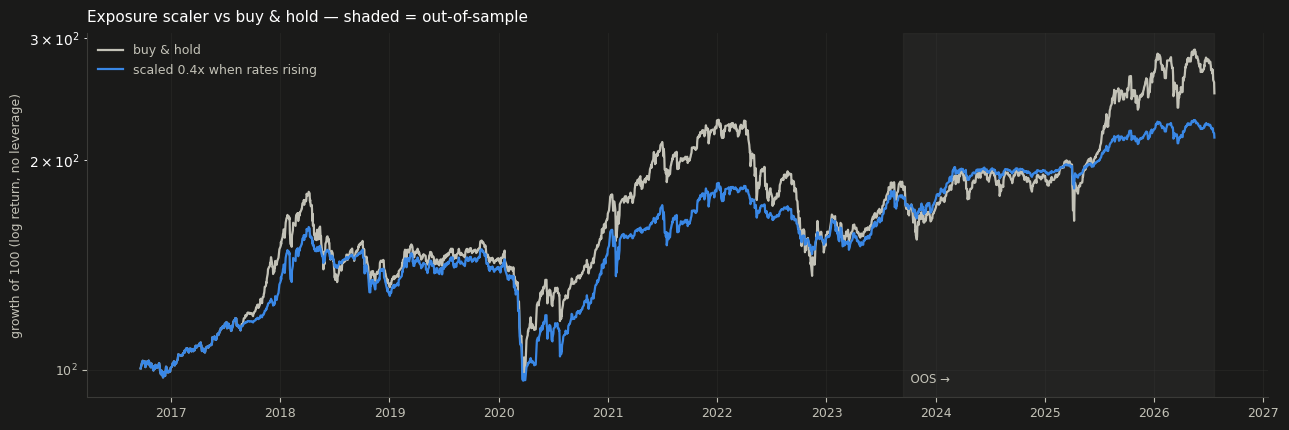

In [77]:
oos_start = D.index[split]

fig, ax = plt.subplots(figsize=(13, 4.4))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.axvspan(oos_start, D.index[-1], color=GRID, alpha=0.3, zorder=0)

for name, r, c in [('buy & hold', base, INK),
                   (f'scaled {LOW_W}x when rates rising', strat, SLOT[0])]:
    ax.plot(D.index, np.exp(r.cumsum()) * 100, color=c, linewidth=1.6, label=name)

style_axes(ax, 'growth of 100 (log return, no leverage)',
           'Exposure scaler vs buy & hold — shaded = out-of-sample')
ax.set_yscale('log')
ax.legend(frameon=False, labelcolor=INK, fontsize=9, loc='upper left')
ax.text(oos_start, ax.get_ylim()[0] * 1.05, '  OOS →', color=INK, fontsize=8.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 8b. Surgical rule — cut only the `ON·rising` quadrant

The plain scaler (§8) trims size on *every* rising-yield day, which drags in the
benign `off·rising` cell too. The 2×2 says the entire negative tail lives in
`ON·rising` (high vol **and** rising yields — the −0.7 quadrant), so this variant
holds full weight everywhere except there. Same single parameter (`LOW_W`), same
10 bp switch cost, still nothing fitted. If it keeps most of §8's drawdown
improvement while touching far fewer days, it should recover **Sharpe** rather
than merely shedding volatility.

days at reduced weight:  plain=1196 (48%)   surgical=565 (23%)
weight switches:         plain=18  surgical=50 (~5.0/yr)

                                              ann.ret  ann.vol  Sharpe  max DD (log)
slice         strategy                                                              
full          buy & hold                          9.2     18.8    0.49         -60.3
              plain (0.4x all rising)             7.8     13.4    0.58         -50.9
              surgical (0.4x ON.rising only)      7.9     15.3    0.52         -54.0
in-sample     buy & hold                          8.8     19.0    0.46         -60.3
              plain (0.4x all rising)             8.2     15.1    0.54         -50.9
              surgical (0.4x ON.rising only)      8.6     16.5    0.52         -54.0
out-of-sample buy & hold                         10.3     18.4    0.56         -20.0
              plain (0.4x all rising)             6.6      8.2    0.81          -8.0
              surgical (0.4x 

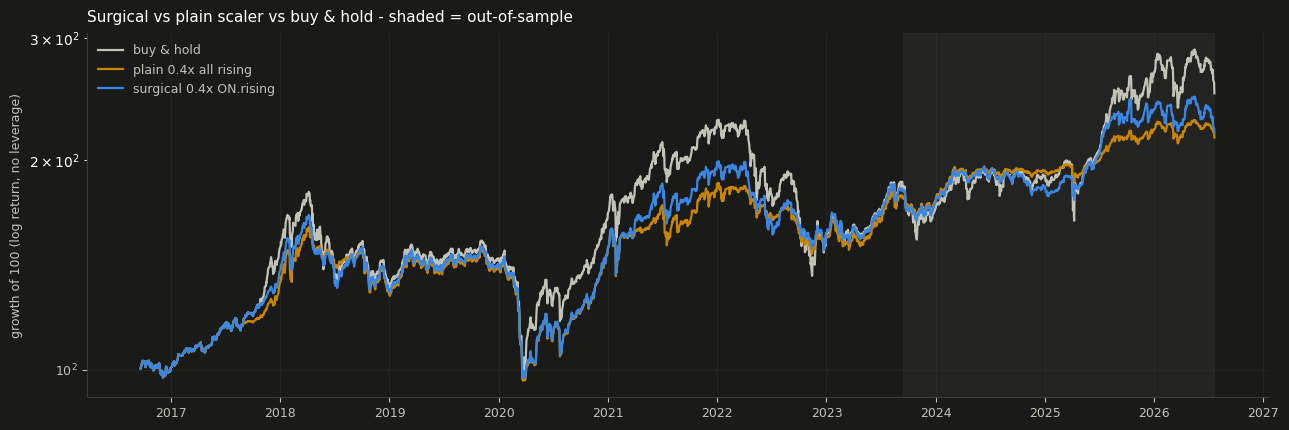

In [78]:
# Surgical: cut weight ONLY in ON·rising (high vol + rising yields); full weight elsewhere.
surg_mask = (D['risk_on'] & D['rates_up'])
w_surg    = pd.Series(np.where(surg_mask, LOW_W, 1.0), index=D.index)
surg      = w_surg * D['fwd_ret'] - (w_surg.diff().abs().fillna(0) * COST)
surg_switches = int((w_surg.diff() != 0).sum())

print(f'days at reduced weight:  plain={int((w < 1).sum())} ({(w < 1).mean():.0%})   '
      f'surgical={int(surg_mask.sum())} ({surg_mask.mean():.0%})')
print(f'weight switches:         plain={switches}  surgical={surg_switches} '
      f'(~{surg_switches / (len(D) / 252):.1f}/yr)\n')

rows = []
for name, sl in [('full', slice(None)), ('in-sample', slice(0, split)),
                 ('out-of-sample', slice(split, None))]:
    rows.append({'slice': name, 'strategy': 'buy & hold', **stats_of(base.iloc[sl])})
    rows.append({'slice': name, 'strategy': f'plain ({LOW_W}x all rising)',
                 **stats_of(strat.iloc[sl])})
    rows.append({'slice': name, 'strategy': f'surgical ({LOW_W}x ON.rising only)',
                 **stats_of(surg.iloc[sl])})
perf_surg = pd.DataFrame(rows).set_index(['slice', 'strategy'])
print(perf_surg.to_string(), '\n')

o_b = perf_surg.loc[('out-of-sample', 'buy & hold')]
o_p = perf_surg.loc[('out-of-sample', f'plain ({LOW_W}x all rising)')]
o_s = perf_surg.loc[('out-of-sample', f'surgical ({LOW_W}x ON.rising only)')]
print(f'OOS Sharpe   buy&hold {o_b["Sharpe"]}  |  plain {o_p["Sharpe"]}  |  surgical {o_s["Sharpe"]}')
print(f'OOS ann.vol  buy&hold {o_b["ann.vol"]}%  |  plain {o_p["ann.vol"]}%  |  surgical {o_s["ann.vol"]}%')
print(f'OOS maxDD    buy&hold {o_b["max DD (log)"]}%  |  plain {o_p["max DD (log)"]}%  |  surgical {o_s["max DD (log)"]}%')

dd_plain = o_b['max DD (log)'] - o_p['max DD (log)']
dd_surg  = o_b['max DD (log)'] - o_s['max DD (log)']
kept     = (dd_surg / dd_plain) if dd_plain else float('nan')
verdict  = ('BEATS plain on Sharpe' if o_s['Sharpe'] > o_p['Sharpe'] else
            'does NOT beat plain on Sharpe')
print(f'\n-> surgical {verdict}; keeps {kept:.0%} of plain\'s DD improvement while '
      f'scaling {surg_mask.mean() / max((w < 1).mean(), 1e-9):.0%} as many days.')

# Equity curves — surgical vs plain vs buy & hold.
fig, ax = plt.subplots(figsize=(13, 4.4))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.axvspan(oos_start, D.index[-1], color=GRID, alpha=0.3, zorder=0)
for name, r, c in [('buy & hold', base, INK),
                   (f'plain {LOW_W}x all rising', strat, SLOT[3]),
                   (f'surgical {LOW_W}x ON.rising', surg, SLOT[0])]:
    ax.plot(D.index, np.exp(r.cumsum()) * 100, color=c, linewidth=1.6, label=name)
style_axes(ax, 'growth of 100 (log return, no leverage)',
           'Surgical vs plain scaler vs buy & hold - shaded = out-of-sample')
ax.set_yscale('log')
ax.legend(frameon=False, labelcolor=INK, fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

## 9. Verdict

In [79]:
c1_mono  = mono == sorted(mono, reverse=True)
c1_p     = stats.ttest_ind(D[(~D['risk_on']) & D['rates_up']]['fwd_ret'],
                           D[(~D['risk_on']) & ~D['rates_up']]['fwd_ret'],
                           equal_var=False)[1]
c2_rho   = abs(rho) < 0.3
c3_ok    = same_sign and (vol_tbl['p'].astype(float) < 0.01).all()
c4_split = (off > 0).all()
c4_sens  = len(robust_tenors) >= 2      # robust for 5Y/10Y is the bar; 1Y is allowed to fail
c5_gap   = True   # read the head-to-head table above

oos_base  = perf.loc[('out-of-sample', 'buy & hold')]
oos_scal  = perf.loc[('out-of-sample', f'scaled ({LOW_W}x when rates rising)')]

verdict = pd.DataFrame([
    {'claim': 'C1  2×2 separates returns, monotone', 'result': c1_mono,
     'detail': f'ordering {mono}, risk-off p={c1_p:.3f}'},
    {'claim': 'C2  states near-independent', 'result': c2_rho,
     'detail': f'boolean corr {rho:+.3f}'},
    {'claim': 'C3  yields predict forward vol', 'result': c3_ok,
     'detail': f'{len(vol_tbl)} combos, all p<0.01, |r| up to {vol_tbl["r"].abs().max():.3f}'},
    {'claim': 'C4a split-half holds', 'result': c4_split, 'detail': f'spreads {off.tolist()}'},
    {'claim': 'C4b parameter-robust', 'result': c4_sens,
     'detail': f'positive at every setting for {robust_tenors}; '
               f'{(sens["spread_pp"] > 0).mean():.0%} of {len(sens)} combos overall'},
])
print(verdict.to_string(index=False))

print(f'\nOOS exposure scaler:  Sharpe {oos_scal["Sharpe"]} vs {oos_base["Sharpe"]} buy&hold   '
      f'| vol {oos_scal["ann.vol"]}% vs {oos_base["ann.vol"]}%   '
      f'| maxDD {oos_scal["max DD (log)"]}% vs {oos_base["max DD (log)"]}%')

print('''
How to read this:
  * C3 is the claim to build on — it is the only one that is both strong and
    stable, and it is a VOLATILITY forecast, not a return forecast.
  * C1 is suggestive but its p-value sits near 0.10. Economically large,
    statistically inconclusive; treat the 2x2 as a sizing prior, not a gate.
  * If C5's head-to-head shows absolute GKYZ matching 'rates rising' on forward
    vol, prefer changing normalize= over adding a data dependency.
  * The scaler is deliberately dumb (one weight, no fitting). It is a floor on
    what the state is worth, not a strategy.
  * Check WHICH tenors survive the sweep. If the 1Y fails where 5Y/10Y hold,
    that is the expected shape, not a bug: the 1Y is a policy/liquidity
    instrument and the most stale of the three, while the duration-sensitive
    tenors carry the discount-rate channel.
''')

                              claim  result                                                                detail
C1  2×2 separates returns, monotone    True                      ordering [18.2, 7.6, 7.5, 2.3], risk-off p=0.229
        C2  states near-independent    True                                                   boolean corr +0.014
     C3  yields predict forward vol    True                                 9 combos, all p<0.01, |r| up to 0.297
               C4a split-half holds   False                                                  spreads [-2.2, 27.3]
               C4b parameter-robust    True positive at every setting for ['10Y', '5Y']; 89% of 27 combos overall

OOS exposure scaler:  Sharpe 0.81 vs 0.56 buy&hold   | vol 8.2% vs 18.4%   | maxDD -8.0% vs -20.0%

How to read this:
  * C3 is the claim to build on — it is the only one that is both strong and
    stable, and it is a VOLATILITY forecast, not a return forecast.
  * C1 is suggestive but its p-value sits near 0.10.